# Analyse - Data_Cannabis.csv

Ce notebook reprend les étapes suivantes :

1. Importation des données
2. Visualisation exploratoire
3. PCA et visualisation
4. Classification supervisée

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
TEST_SIZE = 0.25

## 1) Importation des données

In [ ]:
candidate_paths = [
    Path("data/Data_Cannabis.csv"),
    Path("labs/data/Data_Cannabis.csv"),
]

data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Data_Cannabis.csv introuvable."
        " Verifier le dossier de travail du notebook."
    )

df = pd.read_csv(data_path, sep=";")
print(f"Fichier chargé: {data_path}")
print(f"Dimensions: {df.shape[0]} lignes x {df.shape[1]} colonnes")
display(df.head())
display(df.dtypes.to_frame("dtype"))
display(df.isna().sum().to_frame("nb_valeurs_manquantes"))

Fichier charge: data\Data_Cannabis.csv
Dimensions: 870 lignes x 19 colonnes


,Echantillons,Etat,Var,Squalane,BetaCaryophyllene,AlphaCaryophyllene,Guaiol,gEudesmol,Bulnesol,AlphaBisabolol,Cannabinoide1,THV,Cannabinoide2,CBL,CBDCBC,D9THC,CBG,CBN,Nonacosane
0,AF001_a,Stupefiant,AF,3591971,1105,1597,0,0,0,4771,909,1771,1984,2684,92867,194054,2131,5355,19415
1,AF001_b,Stupefiant,AF,3527968,1189,1539,0,0,0,4613,870,1787,2715,2814,93359,192926,2456,5580,19947
2,AF001_c,Stupefiant,AF,4447698,1172,1523,0,0,0,4428,892,2299,2738,4828,173416,269246,1790,8637,21667
3,AF002_a,Stupefiant,AF,3563450,2589,3375,0,0,0,9055,2823,7606,8580,9529,451489,782277,11349,21198,46424
4,AF002_b,Stupefiant,AF,3559363,2336,3156,0,0,0,8219,2569,7344,8130,9445,450481,781803,10920,20654,43958


,dtype
Echantillons,str
Etat,str
Var,str
Squalane,int64
BetaCaryophyllene,int64
AlphaCaryophyllene,int64
Guaiol,int64
gEudesmol,int64
Bulnesol,int64
AlphaBisabolol,int64


,nb_valeurs_manquantes
Echantillons,0
Etat,0
Var,0
Squalane,0
BetaCaryophyllene,0
AlphaCaryophyllene,0
Guaiol,0
gEudesmol,0
Bulnesol,0
AlphaBisabolol,0


In [ ]:
target_col = "Etat"
print("Répartition de la cible:")
display(df[target_col].value_counts().to_frame("count"))

Repartition de la cible:


,count
Etat,
Fibre,473
Stupefiant,397


## 2) Exploration des données

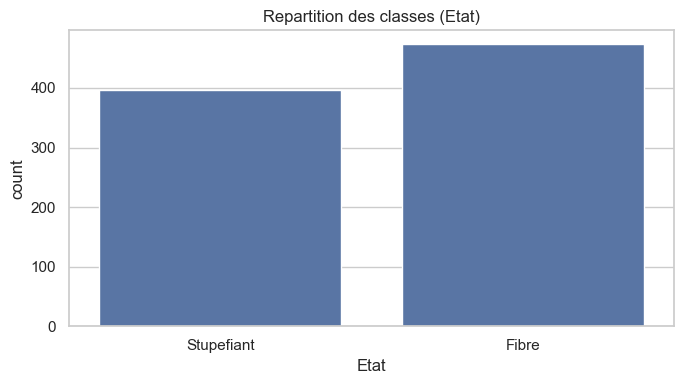

In [ ]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x=target_col)
plt.title("Répartition des classes (Etat)")
plt.tight_layout()
plt.show()

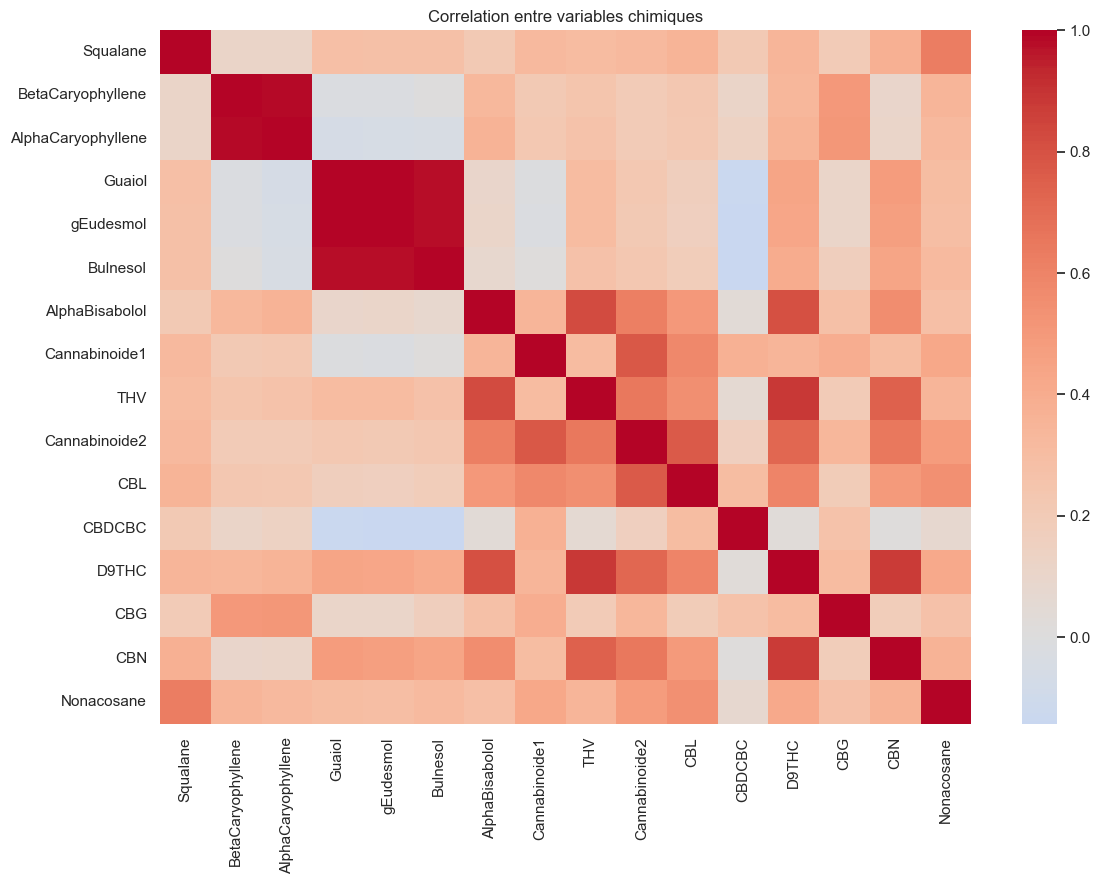

In [ ]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation entre variables")
plt.tight_layout()
plt.show()

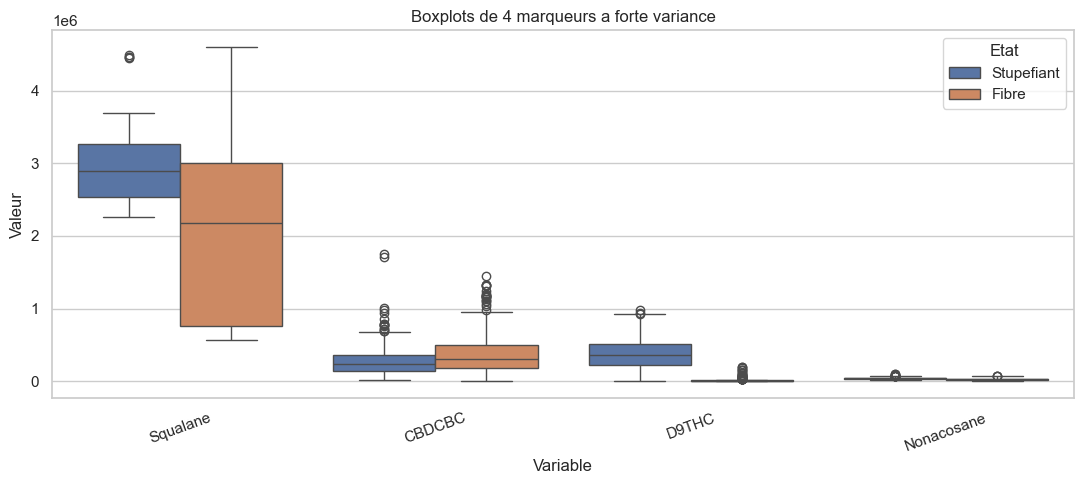

In [ ]:
top4 = (
    df[numeric_cols]
    .var()
    .sort_values(ascending=False)
    .head(4)
    .index
    .tolist()
)

long_df = df[[target_col] + top4].melt(
    id_vars=target_col, var_name="Variable", value_name="Valeur"
)

plt.figure(figsize=(11, 5))
sns.boxplot(data=long_df, x="Variable", y="Valeur", hue=target_col)
plt.title("Boxplots de 4 marqueurs à forte variance")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 3) PCA et visualisation

Variance expliquee PC1: 0.392
Variance expliquee PC2: 0.189
Variance expliquee cumulee: 0.581


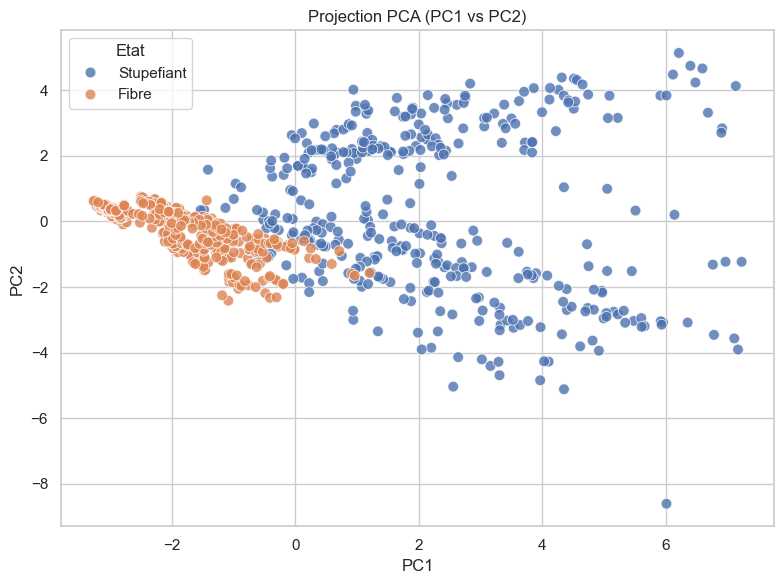

In [ ]:
X = df[numeric_cols]
y = df[target_col]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df[target_col] = y.values

explained = pca.explained_variance_ratio_
print(f"Variance expliquée PC1: {explained[0]:.3f}")
print(f"Variance expliquée PC2: {explained[1]:.3f}")
print(f"Variance expliquée cumulée: {explained.sum():.3f}")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue=target_col, s=60, alpha=0.8)
plt.title("Projection PCA (PC1 vs PC2)")
plt.tight_layout()
plt.show()

## 4) Classification supervisée

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

models = {
    "LogisticRegression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
        ]
    ),
    "RandomForest": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
        ]
    ),
}

results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, pos_label="Stupefiant")

    results.append({"modele": name, "accuracy": acc, "f1_stupefiant": f1})
    trained_models[name] = model

    print("-" * 70)
    print(f"Modele: {name}")
    print(f"Accuracy: {acc:.3f}")
    print(f"F1 (Stupefiant): {f1:.3f}")
    print(classification_report(y_test, pred))

results_df = pd.DataFrame(results).sort_values(by="f1_stupefiant", ascending=False)
display(results_df)

----------------------------------------------------------------------
Modele: LogisticRegression
Accuracy: 0.991
F1 (Stupefiant): 0.990
              precision    recall  f1-score   support

       Fibre       0.98      1.00      0.99       119
  Stupefiant       1.00      0.98      0.99        99

    accuracy                           0.99       218
   macro avg       0.99      0.99      0.99       218
weighted avg       0.99      0.99      0.99       218

----------------------------------------------------------------------
Modele: RandomForest
Accuracy: 0.986
F1 (Stupefiant): 0.985
              precision    recall  f1-score   support

       Fibre       0.98      1.00      0.99       119
  Stupefiant       1.00      0.97      0.98        99

    accuracy                           0.99       218
   macro avg       0.99      0.98      0.99       218
weighted avg       0.99      0.99      0.99       218



,modele,accuracy,f1_stupefiant
0,LogisticRegression,0.990826,0.989796
1,RandomForest,0.986239,0.984615


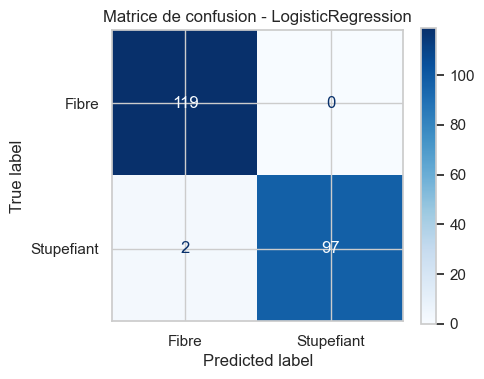

In [9]:
best_name = results_df.iloc[0]["modele"]
best_model = trained_models[best_name]
best_pred = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, ax=ax, cmap="Blues")
ax.set_title(f"Matrice de confusion - {best_name}")
plt.tight_layout()
plt.show()

## Pistes de modifications

- Changer `TEST_SIZE` et `RANDOM_STATE`
- Changer la cible `target_col`
- Ajouter d'autres modeles (KNN, SVM)
- Ajouter d'autres graphiques exploratoires